In [3]:
!pip install trimesh shapely

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 11.6 MB/s eta 0:00:00


In [4]:
from google.colab import files
import trimesh
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [5]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

Saving image_smpl.obj to image_smpl.obj


In [6]:
mesh = trimesh.load(
    filename,
    process=False
)
print("Mesh Loaded Successfully!")
print(mesh.bounds)

Mesh Loaded Successfully!
[[-0.4460701  -0.96109247 -0.19076708]
 [ 0.47041982  0.8380236   0.38450861]]


In [7]:
angle = np.radians(15)

rotation_matrix = trimesh.transformations.rotation_matrix(
    angle,
    [1, 0, 0]
)

mesh.apply_transform(rotation_matrix)

<trimesh.Trimesh(vertices.shape=(10475, 3), faces.shape=(20908, 3))>

In [8]:
waist_y = 0.1

In [9]:
section = mesh.section(
    plane_origin=[0, waist_y, 0],
    plane_normal=[0, 1, 0]
)

if section is None:
    raise ValueError("No waist slice detected!")

In [10]:
curves = section.discrete

print("Contours Detected:", len(curves))

Contours Detected: 3


In [11]:
largest_curve = None
largest_length = 0

for curve in curves:

    closed_curve = np.vstack([
        curve,
        curve[0]
    ])

    segment_lengths = np.linalg.norm(
        np.diff(closed_curve, axis=0),
        axis=1
    )

    total_length = np.sum(segment_lengths)

    if total_length > largest_length:

        largest_length = total_length
        largest_curve = closed_curve

In [12]:
print("====================================")

print(
    "Waist Circumference:",
    round(largest_length, 4)
)
print(
    "Waist Height (Y):",
    waist_y
)
print("====================================")

Waist Circumference: 1.0747
Waist Height (Y): 0.1


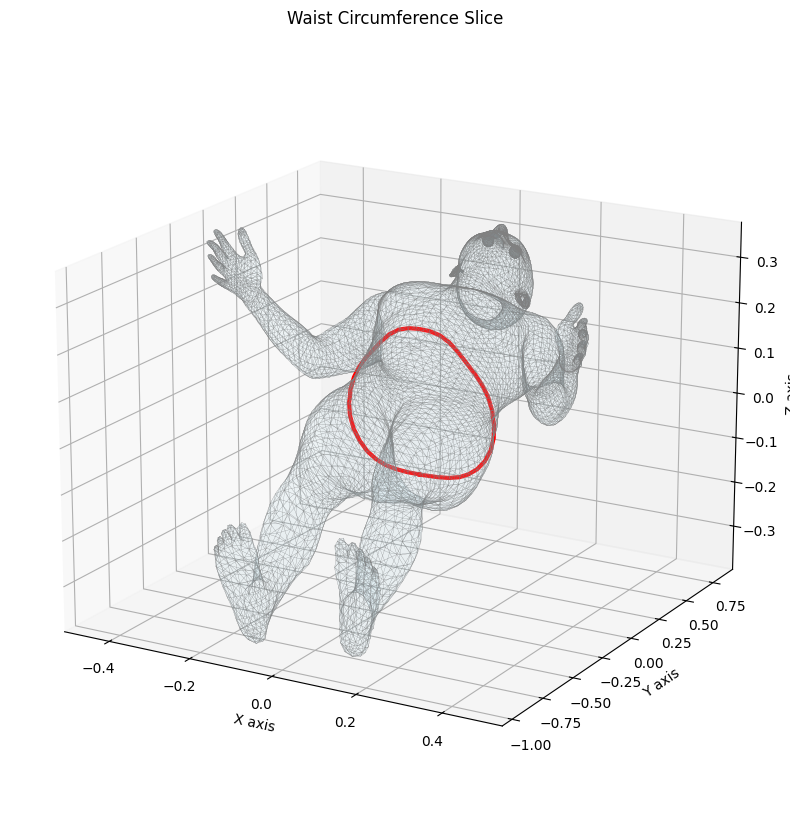

In [21]:

fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(
    111,
    projection='3d'
)
mesh_triangles = mesh.vertices[
    mesh.faces
]
body_mesh = Poly3DCollection(

    mesh_triangles,

    facecolor='lightblue',
    edgecolor='gray',

    linewidth=0.1,
    alpha=0.08
)

ax.add_collection3d(
    body_mesh
)

ax.plot(

    largest_curve[:, 0],
    largest_curve[:, 1],
    largest_curve[:, 2],

    color='red',
    linewidth=3
)

ax.auto_scale_xyz(

    mesh.vertices[:, 0],
    mesh.vertices[:, 1],
    mesh.vertices[:, 2]
)


ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
ax.set_zlabel("Z axis")
ax.set_title(
    "Waist Circumference Slice",
    pad=20
)

ax.grid(True)
ax.view_init(

    elev=18,
    azim=-60
)
plt.show()